### Only for presentation, not for backend

In [1]:
import os

import pandas as pd
path = os.path.expanduser("/Users/avomine/VSCode/ML/Third_Eye/Datasets/Phishing_Email.csv")
df1 = pd.read_csv(path)

In [2]:
df1.columns

Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='str')

In [3]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  18650 non-null  int64
 1   Email Text  18634 non-null  str  
 2   Email Type  18650 non-null  str  
dtypes: int64(1), str(2)
memory usage: 437.2 KB


In [4]:
df1 = df1.drop(columns=['Unnamed: 0'])
df1.head()


,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [5]:
df = df1.copy()

### Renaming columns

In [6]:
df.columns = ['text', 'label']
df['label'].value_counts()

label
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

### Text Processing Pipeline
* using regular expression python module (re)

In [7]:
import re

def clean_text(text):
    text = str(text)        #treat all input as string
    text = text.lower()     #smaller case
    text = text.replace('\n', ' ')   # remove line breaks
    text = re.sub(r"http\S+", " ", text)    # drops all https 
    text = re.sub(r"[^a-z ]", " ", text)    #everything that isnt a-z replce with space
    text = re.sub(r"\s+", " ", text)        #collapse multiple spaces to 1 space
    return text.strip()             #trims all lingering spaces

df['text'] = df['text'].fillna("").astype(str)  #find all empty places and replace w blank string
df['text'] = df['text'].apply(clean_text)       #apply the changes and create cleaner column

### Cleaned email entires

In [8]:
df.head()

,text,label
0,re disc uniformitarianism re sex lang dick hud...,Safe Email
1,the other side of galicismos galicismo is a sp...,Safe Email
2,re equistar deal tickets are you still availab...,Safe Email
3,hello i am your hot lil horny toy i am the one...,Phishing Email
4,software at incredibly low prices lower draper...,Phishing Email


### Class Distribution

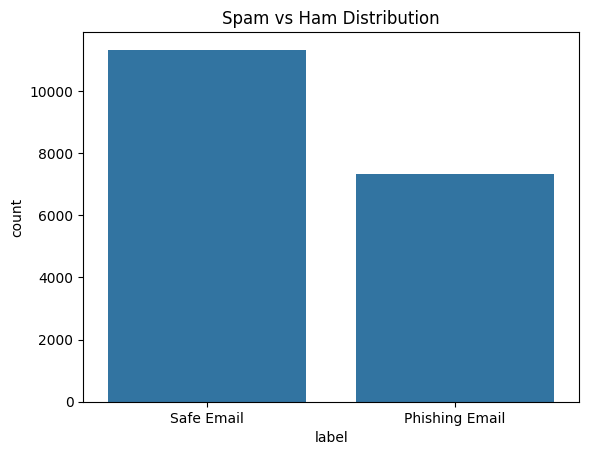

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['label'])
plt.title("Spam vs Ham Distribution")
plt.show()

### Email Length Categorization and Distribution

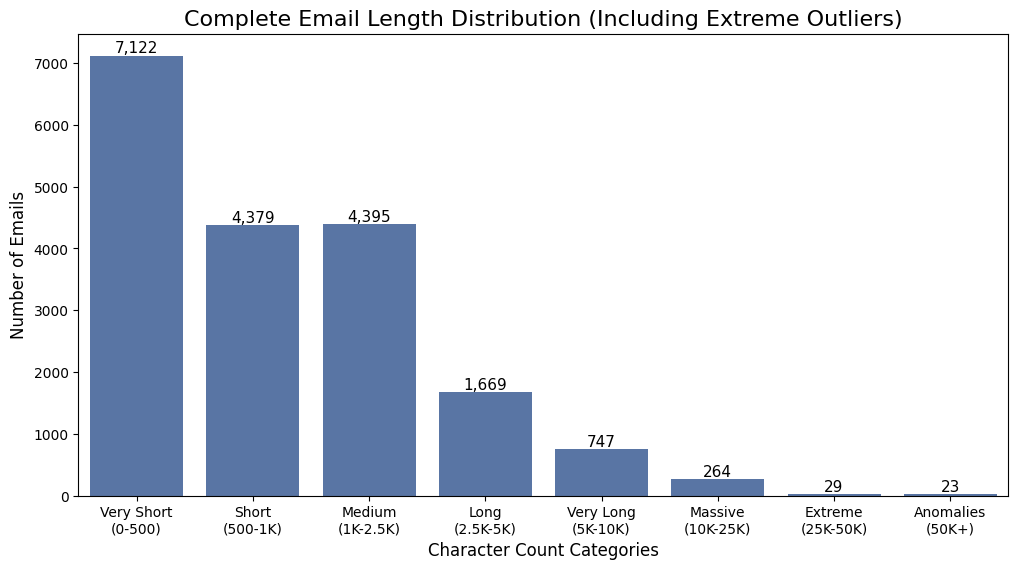

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define Progressive Boundaries (Gets wider as numbers get bigger)
bins = [0, 500, 1000, 2500, 5000, 10000, 25000, 50000, np.inf]

# Creating labels
labels = [
    "Very Short\n(0-500)",
    "Short\n(500-1K)",
    "Medium\n(1K-2.5K)",
    "Long\n(2.5K-5K)",
    "Very Long\n(5K-10K)",
    "Massive\n(10K-25K)",
    "Extreme\n(25K-50K)",
    "Anomalies\n(50K+)"
]

# 3. Categorize the data and count the totals
df['length'] = df['text'].apply(len)
df['size_category'] = pd.cut(df['length'], bins=bins, labels=labels)
bucket_counts = df['size_category'].value_counts().reindex(labels)

plt.figure(figsize=(12, 6))
sns.barplot(x=bucket_counts.index, y=bucket_counts.values, color='#4C72B0')

# 5. Write the exact number on top of each bar for the audience
for index, value in enumerate(bucket_counts.values):
    plt.text(index, value, f'{value:,}', ha='center', va='bottom', fontsize=11)

# 6. Format titles and labels
plt.title("Complete Email Length Distribution (Including Extreme Outliers)", fontsize=16)
plt.xlabel("Character Count Categories", fontsize=12)
plt.ylabel("Number of Emails", fontsize=12)

# Clean up layout and display
plt.show()

### New Dataset
* Additions - Labels, Length, Size Category

In [11]:
df.head(15)

,text,label,length,size_category
0,re disc uniformitarianism re sex lang dick hud...,Safe Email,907,Short\n(500-1K)
1,the other side of galicismos galicismo is a sp...,Safe Email,443,Very Short\n(0-500)
2,re equistar deal tickets are you still availab...,Safe Email,964,Short\n(500-1K)
3,hello i am your hot lil horny toy i am the one...,Phishing Email,460,Very Short\n(0-500)
4,software at incredibly low prices lower draper...,Phishing Email,384,Very Short\n(0-500)
5,global risk management operations sally congra...,Safe Email,2989,Long\n(2.5K-5K)
6,on sun aug at am wintermute mentioned the impr...,Safe Email,781,Short\n(500-1K)
7,entourage stockmogul newsletter ralph velez ge...,Phishing Email,6989,Very Long\n(5K-10K)
8,we owe you lots of money dear applicant after ...,Phishing Email,504,Short\n(500-1K)
9,re coastal deal with exxon participation under...,Safe Email,1669,Medium\n(1K-2.5K)


### Most common words in emails

In [12]:
from collections import Counter

words= ' '.join(df['text']).split()
Counter(words).most_common(20)

[('the', 301875),
 ('of', 188273),
 ('to', 182080),
 ('and', 170547),
 ('a', 129869),
 ('in', 118243),
 ('for', 82584),
 ('is', 74962),
 ('you', 71686),
 ('i', 59621),
 ('on', 57491),
 ('that', 56633),
 ('this', 52435),
 ('be', 49186),
 ('it', 45565),
 ('s', 45019),
 ('with', 41961),
 ('are', 38386),
 ('as', 37515),
 ('or', 36802)]

### Train, Test Split, 80% train and 20% test

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

### Using Label Encoder to transform categorical text based label into numerical integers

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train =le.fit_transform(y_train)
y_test =le.transform(y_test)

### Feature Extraction using TF-IDF Vectorizer 
> Term Frequency - Inverse Document Frequency 
* Measures how frequently a word appears in document and how important it is (A product of TF and IDF scores)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)  # important improvement
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

### Model 1: Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

### Model 2: Naive Bayes 

In [17]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)

### Evaluation

In [18]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      1457
           1       0.97      0.97      0.97      2273

    accuracy                           0.96      3730
   macro avg       0.96      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730

Naive Bayes:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      1457
           1       0.96      0.95      0.96      2273

    accuracy                           0.95      3730
   macro avg       0.95      0.95      0.95      3730
weighted avg       0.95      0.95      0.95      3730



### Confusion Matrix

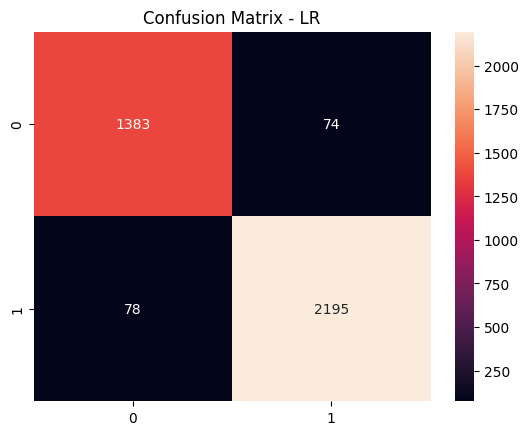

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - LR")
plt.show()

In [20]:
import numpy as np

def test_new_email(new_email_text, trained_model, fitted_vectorizer, label_encoder):
    """
    Takes raw email text, cleans it, and returns the classification with confidence scores.
    """
    print("-" * 40)
    
    # 1. Clean the email text using your existing clean_text function
    cleaned_email = clean_text(new_email_text)
    
    # 2. Vectorize the text using your fitted TF-IDF vectorizer
    vectorized_email = fitted_vectorizer.transform([cleaned_email])
    
    # 3. Get the numerical prediction and the probability array
    prediction_num = trained_model.predict(vectorized_email)[0]
    probabilities = trained_model.predict_proba(vectorized_email)[0]
    
    # 4. Use your LabelEncoder to translate the number back into the text label
    prediction_text = label_encoder.inverse_transform([prediction_num])[0]
    
    # 5. Output the main classification result (dynamically checking for spam/phishing words)
    if "phish" in str(prediction_text).lower() or "spam" in str(prediction_text).lower():
        print(f"🚨 Classification: {str(prediction_text).upper()}")
    else:
        print(f"✅ Classification: {str(prediction_text).upper()}")
        
    print("\nConfidence Breakdown:")
    # 6. Loop through the classes dynamically to show the exact percentage for each
    for i, class_name in enumerate(label_encoder.classes_):
        prob_percentage = probabilities[i] * 100
        print(f" - {class_name}: {prob_percentage:.2f}%")
    print("\n" + "="*40 + "\n")


# --- Let's test it using some simulated emails! ---

# A normal, safe corporate email
safe_email = """
Hi Team,
Just a reminder that our weekly stand-up meeting is moved to 10:30 AM tomorrow. 
Please make sure to update your Jira tickets before the call.
Best,
John
"""
test_new_email(safe_email, lr, vectorizer, le)

# A classic phishing / spam email
phishing_email = """
URGENT: Your PayPal account has been compromised!
Please click on the link below immediately to verify your identity and secure your funds. 
http://secure-update-paypal-account2026.com/login
Failure to do so will result in permanent account suspension.
"""
test_new_email(phishing_email, lr, vectorizer, le)

# A promotional email that might sit on the borderline
promo_email = """
Congratulations! You've been selected to receive a 50% discount on all our premium shoes.
Limited time offer. Buy now and get free shipping! 
Unsubscribe here.
"""
test_new_email(promo_email, lr, vectorizer, le)

----------------------------------------
✅ Classification: SAFE EMAIL

Confidence Breakdown:
 - Phishing Email: 14.97%
 - Safe Email: 85.03%


----------------------------------------
🚨 Classification: PHISHING EMAIL

Confidence Breakdown:
 - Phishing Email: 94.86%
 - Safe Email: 5.14%


----------------------------------------
🚨 Classification: PHISHING EMAIL

Confidence Breakdown:
 - Phishing Email: 95.70%
 - Safe Email: 4.30%


